In [1]:
import pandas as pd
import numpy as np
import os, sys
import subprocess

import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rc("axes",labelsize="large")

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['text.usetex'] = False

import ewpo

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport ewpo

sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

%aimport fit_utils
%aimport fit_utils.utils
%aimport fit_utils.pullplots
%aimport fit_utils.parser
%aimport fit_utils.EFT_matching

import fit_utils.utils as utils
import fit_utils.pullplots as pullplots
import fit_utils.parser as parser
import fit_utils.EFT_matching as EFT_matching

In [2]:
Mh = 125.1
lamQCD5=210*10**(-3)
vev=246.21965
lam1 = Mh**2/vev**2
alphaem=1/137.035999084
eL = np.sqrt(4*np.pi*alphaem)


def A_f(f, sin2thetaEff):
    if f in ['u', 'c', 't']:
        T3 = 0.5
        Q = 2.0/3.0
    elif f in ['d', 's', 'b']:
        T3 = -0.5
        Q = -1.0/3.0
    elif f in ['e', 'mu', 'tau']:
        T3 = -0.5
        Q = -1.0
    else:
        raise ValueError("Invalid fermion type for A_f calculation")

    gV = T3 - 2*Q*sin2thetaEff
    gA = T3

    return 2*gV*gA/(gV**2 + gA**2)

# Testing decoupling limit: infinite masses 

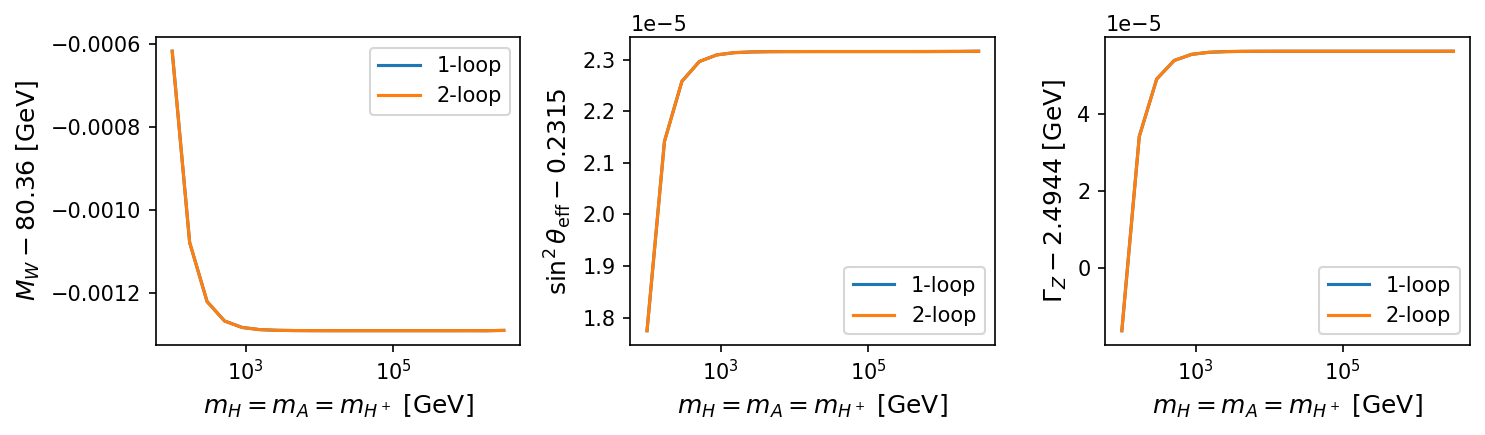

In [19]:
BPs = {}
n_bps = 20
large_mass = np.logspace(2, 6.5, num=n_bps)
BPs['mH'] = large_mass
BPs['mA'] = large_mass
BPs['mHp'] = large_mass
BPs['lam345'] = np.full(n_bps, 0.0)
BPs['MW1L'] = ewpo.MW1L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['sl1L'] = ewpo.sl1L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['GamZ1L'] = ewpo.GamZ1L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['MW2L'] = ewpo.MW2L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['sl2L'] = ewpo.sl2L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['GamZ2L'] = ewpo.GamZ2L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])

# print("1-loop predictions for the benchmark points:")
# for obs in ['MW1L','sl1L','GamZ1L','MW2L','sl2L','GamZ2L']:
#     print(f"{obs} = {BPs[obs]}")

fig, axes = plt.subplots(1, 3, figsize=(10,3))
mw_val = 80.360
axes[0].set_ylabel(rf'$M_W - {mw_val}$ [GeV]')

sl_val = 0.2315
axes[1].set_ylabel(rf'$\sin^2\theta_{{\mathrm{{eff}}}} - {sl_val}$')

gamz_val = 2.4944
axes[2].set_ylabel(rf'$\Gamma_Z - {gamz_val}$ [GeV]')

axes[0].plot(BPs['mH'], BPs['MW1L'] - mw_val, label=r'1-loop')
axes[0].plot(BPs['mH'], BPs['MW2L'] - mw_val, label=r'2-loop')
axes[1].plot(BPs['mH'], BPs['sl1L'] - sl_val, label=r'1-loop')
axes[1].plot(BPs['mH'], BPs['sl2L'] - sl_val, label=r'2-loop')
axes[2].plot(BPs['mH'], BPs['GamZ1L'] - gamz_val, label=r'1-loop')
axes[2].plot(BPs['mH'], BPs['GamZ2L'] - gamz_val, label=r'2-loop')

for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r'$m_H = m_A = m_{H^+}$ [GeV]')
    ax.legend()
plt.tight_layout()

subprocess.run(["mkdir", "-p", "plots"])
plt.savefig("plots/ewpos_comparison_absolute.png")

plt.show()

## Compare $A_f$ predictions

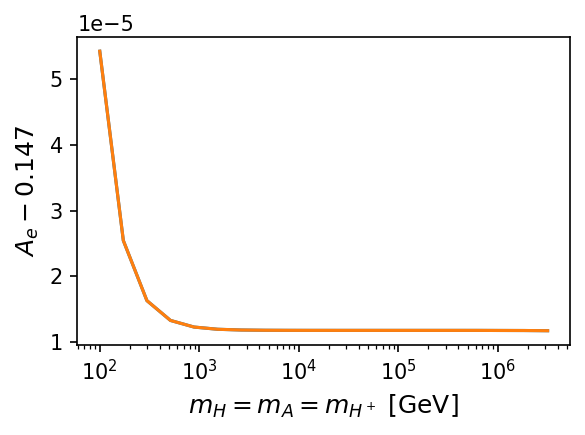

In [20]:
BPs['Ae1L'] = A_f('e', BPs['sl1L'])
BPs['Ae2L'] = A_f('e', BPs['sl2L'])

fig, ax = plt.subplots(1, 1, figsize=(4,3))

Ae_val = 0.147
ax.set_ylabel(rf'$A_e - {Ae_val}$')

ax.set_xscale('log')
ax.set_xlabel(r'$m_H = m_A = m_{H^+}$ [GeV]')
# ax.legend()
ax.plot(BPs['mH'], BPs['Ae1L'] - Ae_val, label=r'1-loop')
ax.plot(BPs['mH'], BPs['Ae2L'] - Ae_val, label=r'2-loop')
plt.tight_layout()
plt.show()

### Reading HEPfit predictions for SM:

In [5]:
from fit_utils.parser import find_configuration_files, read_configuration_files

In [16]:
working_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Fits_HLLHC_FCCee/different_BPs"

all_scenarios = [f"IDM_FCCee240_FCCee365",]

specs = ["."]

model_specs = {}

model_specs = {f"IDM_FCCee240_FCCee365" : specs, }
BP_list = ["BP_lambda1"]

conf_files = find_configuration_files(
    model_specs,
    model="SM",
    read_WCs=False,
)

only_obs = ["Aelectron_FCCee", "Amuon_FCCee", "Atau_FCCee", ]
observables, observables_tex, central_values_obs, input_uncertainties = read_configuration_files(
    working_dir=working_dir,
    BPs=BP_list,
    model_specs=model_specs,
    conf_files=conf_files,
    only_obs=only_obs,
    skip_obs=None,
    only_higgs_fccee_obs=False,
    read_model_parameters=False,
    compare_with_SM=False,
)

print(conf_files)
# print(observables)
# print(observables_tex)
# print(central_values_obs)
# print(input_uncertainties) 

observables = list(list(list(observables.values())[0].values())[0].values())[0]
Ae_hepfit_val = list(list(list(central_values_obs.values())[0].values())[0].values())[0][observables.index("Aelectron_FCCee")]
Ae_hepfit_err = list(list(list(input_uncertainties.values())[0].values())[0].values())[0][observables.index("Aelectron_FCCee")]
print(observables)
print(Ae_hepfit_val)
print(Ae_hepfit_err)
# 

Reading configuration file /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Fits_HLLHC_FCCee/different_BPs/BP_lambda1/IDM_FCCee240_FCCee365/ObservablesEW.conf
Reading configuration file /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Fits_HLLHC_FCCee/different_BPs/BP_lambda1/IDM_FCCee240_FCCee365/ObservablesEW_Current_SM_noLFU.conf
Reading configuration file /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Fits_HLLHC_FCCee/different_BPs/BP_lambda1/IDM_FCCee240_FCCee365/ObservablesEW_FCCee_Zpole_SM.conf
Reading configuration file /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Fits_HLLHC_FCCee/different_BPs/BP_lambda1/IDM_FCCee240_FCCee365/ObservablesEW_FCCee_WW_SM.conf
Reading configuration file /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Fits_HLLHC_FCCee/different_BPs/BP_lambda1/IDM_FCCee240_FCCee365/ObservablesEW_HLLHC.conf
Reading configuration file /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Fits_HLLHC_FC

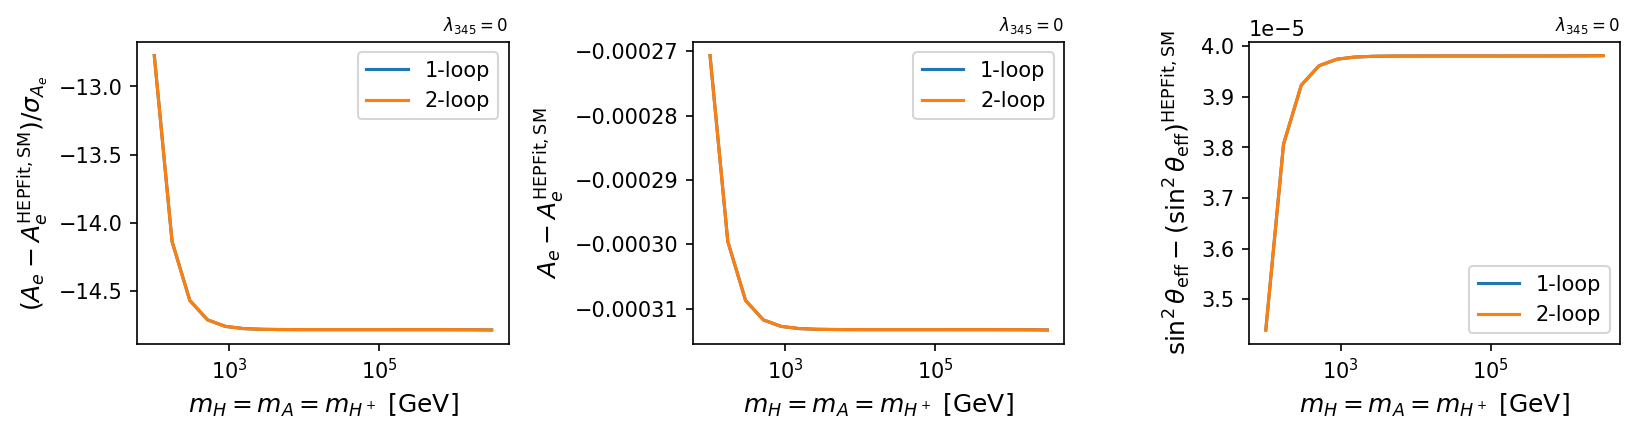

In [21]:
BPs = {}
n_bps = 20
large_mass = np.logspace(2, 6.5, num=n_bps)
BPs['mH'] = large_mass
BPs['mA'] = large_mass
BPs['mHp'] = large_mass
BPs['lam345'] = np.full(n_bps, 0.0)
BPs['MW1L'] = ewpo.MW1L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['sl1L'] = ewpo.sl1L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['GamZ1L'] = ewpo.GamZ1L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['MW2L'] = ewpo.MW2L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['sl2L'] = ewpo.sl2L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])
BPs['GamZ2L'] = ewpo.GamZ2L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'])

BPs['Ae1L'] = A_f('e', BPs['sl1L'])
BPs['Ae2L'] = A_f('e', BPs['sl2L'])

fig, axes = plt.subplots(1, 3, figsize=(11,3))

axes[0].set_ylabel(rf'$(A_e - A_e^{{\mathrm{{HEPFit, SM}}}})/\sigma_{{A_e}}$')
axes[0].text(1, 1.02, r"$\lambda_{345} = 0$", va="bottom", ha="right", transform=axes[0].transAxes, fontsize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$m_H = m_A = m_{H^+}$ [GeV]')
axes[0].plot(BPs['mH'], (BPs['Ae1L'] - Ae_hepfit_val)/Ae_hepfit_err, label=r'1-loop')
axes[0].plot(BPs['mH'], (BPs['Ae2L'] - Ae_hepfit_val)/Ae_hepfit_err, label=r'2-loop')
axes[0].legend()

axes[1].set_ylabel(rf'$A_e - A_e^{{\mathrm{{HEPFit, SM}}}}$')
axes[1].text(1, 1.02, r"$\lambda_{345} = 0$", va="bottom", ha="right", transform=axes[1].transAxes, fontsize=8)
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$m_H = m_A = m_{H^+}$ [GeV]')
axes[1].plot(BPs['mH'], (BPs['Ae1L'] - Ae_hepfit_val), label=r'1-loop')
axes[1].plot(BPs['mH'], (BPs['Ae2L'] - Ae_hepfit_val), label=r'2-loop')
axes[1].legend()


sl_HEPfit_val = 0.2314833512991618
axes[2].set_ylabel(rf'$\sin^2\theta_{{\mathrm{{eff}}}} - (\sin^2\theta_{{\mathrm{{eff}}}} )^{{\mathrm{{HEPFit, SM}}}}$')
axes[2].text(1, 1.02, r"$\lambda_{345} = 0$", va="bottom", ha="right", transform=axes[2].transAxes, fontsize=8)
axes[2].plot(BPs['mH'], BPs['sl1L'] - sl_HEPfit_val, label=r'1-loop')
axes[2].plot(BPs['mH'], BPs['sl2L'] - sl_HEPfit_val, label=r'2-loop')
axes[2].set_xscale('log')
axes[2].set_xlabel(r'$m_H = m_A = m_{H^+}$ [GeV]')
axes[2].legend()
plt.tight_layout()

plt.savefig("plots/ewpos_comparison_relative.png")
plt.show()

# Modifying input parameters

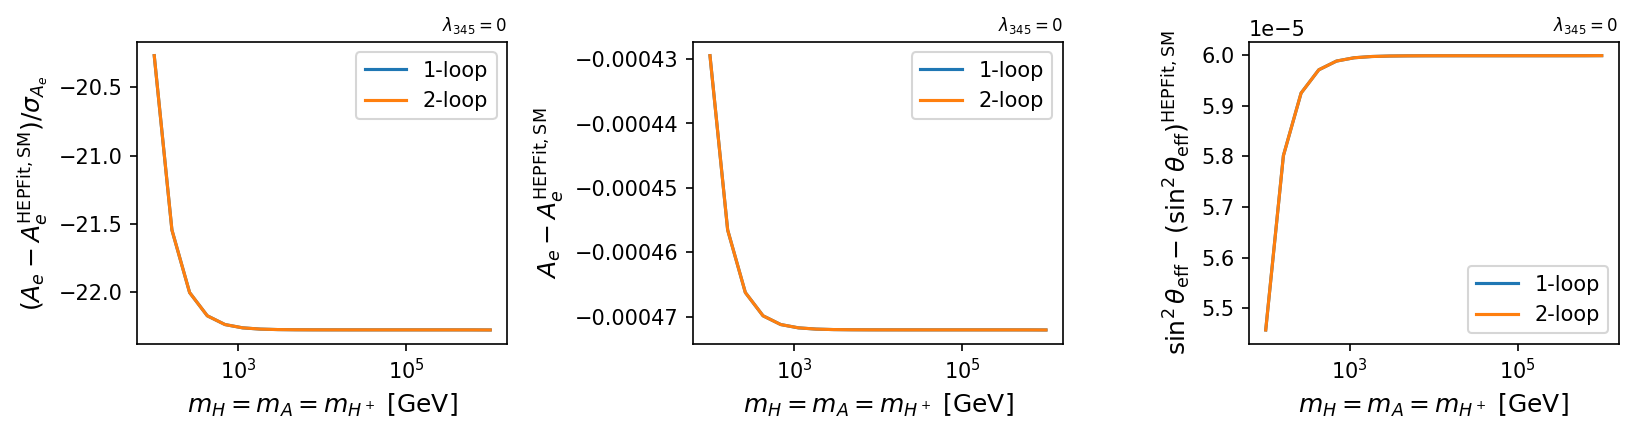

[0.14689552 0.14686844 0.14685873 0.14685511 0.14685375 0.14685324
 0.14685305 0.14685297 0.14685294 0.14685293 0.14685293 0.14685293
 0.14685293 0.14685293 0.14685293 0.14685293 0.14685293 0.14685292
 0.14685292 0.14685291]


In [ ]:
BPs = {}
n_bps = 20
large_mass = np.logspace(2, 6.5, num=n_bps)
BPs['mH'] = large_mass
BPs['mA'] = large_mass
BPs['mHp'] = large_mass
BPs['lam345'] = np.full(n_bps, 1)
BPs['MW1L'] = ewpo.MW1L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'], test=True)
BPs['sl1L'] = ewpo.sl1L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'], test=True)
BPs['GamZ1L'] = ewpo.GamZ1L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'], test=True)
BPs['MW2L'] = ewpo.MW2L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'], test=True)
BPs['sl2L'] = ewpo.sl2L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'], test=True)
BPs['GamZ2L'] = ewpo.GamZ2L_vec(BPs['mH'],BPs['mA'],BPs['mHp'],BPs['lam345'], test=True)

BPs['Ae1L'] = A_f('e', BPs['sl1L'])
BPs['Ae2L'] = A_f('e', BPs['sl2L'])

fig, axes = plt.subplots(1, 3, figsize=(11,3))

axes[0].set_ylabel(rf'$(A_e - A_e^{{\mathrm{{HEPFit, SM}}}})/\sigma_{{A_e}}$')
axes[0].text(1, 1.02, r"$\lambda_{345} = 0$", va="bottom", ha="right", transform=axes[0].transAxes, fontsize=8)
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$m_H = m_A = m_{H^+}$ [GeV]')
axes[0].plot(BPs['mH'], (BPs['Ae1L'] - Ae_hepfit_val)/Ae_hepfit_err, label=r'1-loop')
axes[0].plot(BPs['mH'], (BPs['Ae2L'] - Ae_hepfit_val)/Ae_hepfit_err, label=r'2-loop')
axes[0].legend()

axes[1].set_ylabel(rf'$A_e - A_e^{{\mathrm{{HEPFit, SM}}}}$')
axes[1].text(1, 1.02, r"$\lambda_{345} = 0$", va="bottom", ha="right", transform=axes[1].transAxes, fontsize=8)
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$m_H = m_A = m_{H^+}$ [GeV]')
axes[1].plot(BPs['mH'], (BPs['Ae1L'] - Ae_hepfit_val), label=r'1-loop')
axes[1].plot(BPs['mH'], (BPs['Ae2L'] - Ae_hepfit_val), label=r'2-loop')
axes[1].legend()


sl_HEPfit_val = 0.2314833512991618
axes[2].set_ylabel(rf'$\sin^2\theta_{{\mathrm{{eff}}}} - (\sin^2\theta_{{\mathrm{{eff}}}} )^{{\mathrm{{HEPFit, SM}}}}$')
axes[2].text(1, 1.02, r"$\lambda_{345} = 0$", va="bottom", ha="right", transform=axes[2].transAxes, fontsize=8)
axes[2].plot(BPs['mH'], BPs['sl1L'] - sl_HEPfit_val, label=r'1-loop')
axes[2].plot(BPs['mH'], BPs['sl2L'] - sl_HEPfit_val, label=r'2-loop')
axes[2].set_xscale('log')
axes[2].set_xlabel(r'$m_H = m_A = m_{H^+}$ [GeV]')
axes[2].legend()
plt.tight_layout()
plt.savefig("plots/ewpos_comparison_relative_mod_sm_pars.png")
plt.show()



print(BPs['Ae1L'])